In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('personal_expense_dataset.csv')

In [6]:
import os
os.getcwd()

'C:\\Users\\USER\\PycharmProjects\\JupyterProject\\Data'

In [5]:
df.head()

,Date,Category,Amount,Payment_Mode,Month
0,1/1/2024,Transport,3279,Cash,May
1,1/2/2024,Entertainment,2080,Card,December
2,1/2/2024,Transport,3217,Online,December
3,1/2/2024,Utilities,1054,Online,May
4,1/5/2024,Food,13249,Cash,December


In [6]:
df.shape

(1000, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          1000 non-null   str  
 1   Category      1000 non-null   str  
 2   Amount        1000 non-null   int64
 3   Payment_Mode  1000 non-null   str  
 4   Month         1000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 39.2 KB


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1000 non-null   datetime64[us]
 1   Category      1000 non-null   str           
 2   Amount        1000 non-null   int64         
 3   Payment_Mode  1000 non-null   str           
 4   Month         1000 non-null   str           
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 39.2 KB


In [10]:
df.describe()

,Date,Amount
count,1000,1000.000000
mean,2025-05-18 22:17:45.600000,7676.692000
min,2024-01-01 00:00:00,101.000000
25%,2024-08-30 18:00:00,3781.250000
50%,2025-05-20 00:00:00,7938.000000
75%,2026-01-27 06:00:00,11442.250000
max,2026-09-25 00:00:00,14999.000000
std,NaN,4347.352771


In [11]:
df['Category'].value_counts()

Category
Food             152
Health           151
Entertainment    150
Transport        144
Shopping         144
Rent             144
Utilities        115
Name: count, dtype: int64

In [12]:
df['Payment_Mode'].value_counts()


Payment_Mode
Cash      347
Card      337
Online    316
Name: count, dtype: int64

In [14]:
df['Month'].value_counts()

Month
January      90
May          88
December     88
November     85
June         85
March        84
September    84
August       84
April        83
February     80
July         75
October      74
Name: count, dtype: int64

## 5. Spending Analysis
### 5.1 Total spending by category
Food accounts for the highest total spending while Utilities is the lowest.

In [15]:
df.groupby('Category')['Amount'].sum()

Category
Entertainment    1126859
Food             1225416
Health           1135122
Rent              997894
Shopping         1163286
Transport        1065197
Utilities         962918
Name: Amount, dtype: int64

In [16]:
category_spending = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print(category_spending)

Category
Food             1225416
Shopping         1163286
Health           1135122
Entertainment    1126859
Transport        1065197
Rent              997894
Utilities         962918
Name: Amount, dtype: int64


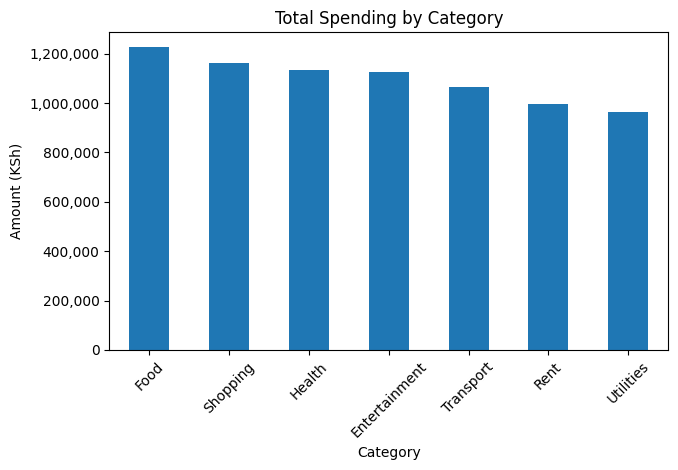

In [20]:
category_spending.plot(kind='bar')
plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount (KSh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

### 5.2 Spending by Payment Mode
Cash accounts for the highest total spending, followed by Card and Online.
This suggests most transactions happen in person rather than digitally.
Spending is fairly evenly distributed across all three payment modes,
suggesting no strong preference for one payment method over another.



In [21]:
payment_spending = df.groupby('Payment_Mode')['Amount'].sum().sort_values(ascending=False)
print(payment_spending)

Payment_Mode
Cash      2661495
Card      2587278
Online    2427919
Name: Amount, dtype: int64


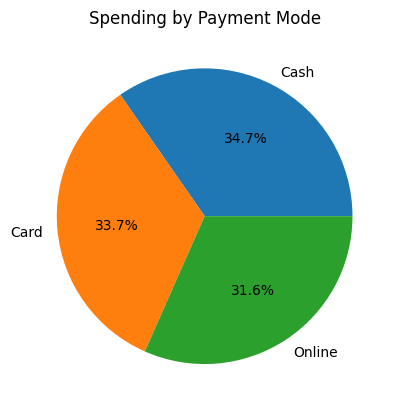

In [22]:
payment_spending.plot(kind='pie', autopct='%1.1f%%')
plt.title('Spending by Payment Mode')
plt.ylabel('')
plt.show()

### 5.3 Spending by Month
August records the highest monthly spending, potentially reflecting
back to school expenses. July shows the lowest spending, suggesting
mid-year budget discipline.

In [23]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_spending = df.groupby('Month')['Amount'].sum()
monthly_spending = monthly_spending.reindex(month_order)
print(monthly_spending)

Month
January      619460
February     628661
March        594558
April        649464
May          682240
June         692346
July         563018
August       721611
September    624093
October      598291
November     694766
December     608184
Name: Amount, dtype: int64


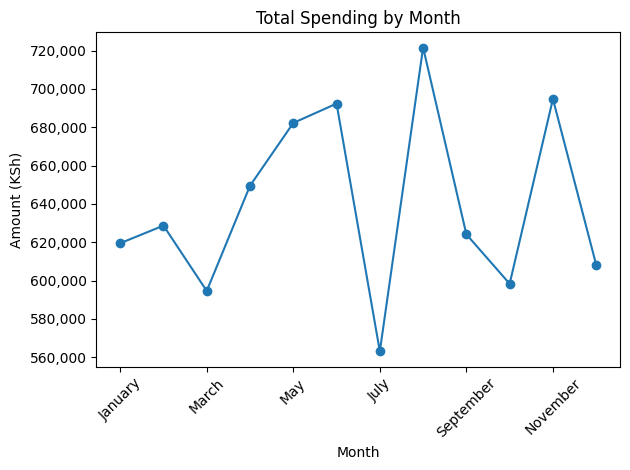

In [24]:
monthly_spending.plot(kind='line', marker='o')
plt.title('Total Spending by Month')
plt.xlabel('Month')
plt.ylabel('Amount (KSh)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Budget Analysis
### 6.1 Setting budget targets
Here we define monthly budget targets per category and compare
against actual average monthly spending.

In [34]:
budgets = {
    'Food': 44000,
    'Transport': 30000,
    'Health': 32000,
    'Entertainment': 35000,
    'Shopping': 33000,
    'Rent': 31000,
    'Utilities': 31000
}
print(category_spending)

Category
Food             1225416
Shopping         1163286
Health           1135122
Entertainment    1126859
Transport        1065197
Rent              997894
Utilities         962918
Name: Amount, dtype: int64


In [28]:
budget_df = pd.DataFrame({
    'Budget': budgets,
    'Actual': category_spending
})

print(budget_df)

               Budget   Actual
Entertainment  115000  1126859
Food           130000  1225416
Health         120000  1135122
Rent           105000   997894
Shopping       120000  1163286
Transport      110000  1065197
Utilities      100000   962918


In [30]:
num_months = (df['Date'].dt.to_period('M')).nunique()
print(num_months)
monthly_avg_spending = df.groupby('Category')['Amount'].sum() / num_months
print(monthly_avg_spending)


33
Category
Entertainment    34147.242424
Food             37133.818182
Health           34397.636364
Rent             30239.212121
Shopping         35251.090909
Transport        32278.696970
Utilities        29179.333333
Name: Amount, dtype: float64


In [35]:
budget_df = pd.DataFrame({
    'Budget': budgets,
    'Actual': monthly_avg_spending
})

budget_df['Difference'] = budget_df['Budget'] - budget_df['Actual']
budget_df['Status'] = budget_df['Difference'].apply(lambda x: 'Over Budget' if x < 0 else 'Under Budget')

print(budget_df)

               Budget        Actual   Difference        Status
Entertainment   35000  34147.242424   852.757576  Under Budget
Food            44000  37133.818182  6866.181818  Under Budget
Health          32000  34397.636364 -2397.636364   Over Budget
Rent            31000  30239.212121   760.787879  Under Budget
Shopping        33000  35251.090909 -2251.090909   Over Budget
Transport       30000  32278.696970 -2278.696970   Over Budget
Utilities       31000  29179.333333  1820.666667  Under Budget


### 6.2 Budget vs Actual Spending
Health and Transport exceed their monthly budget targets, suggesting
these are areas where spending needs to be controlled. All other
categories remain within budget.

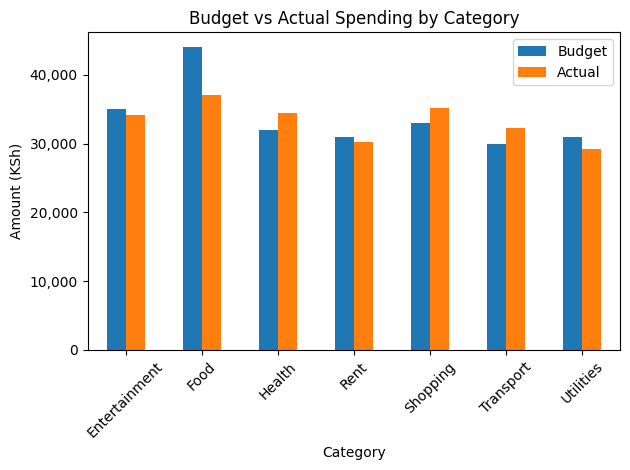

In [36]:
budget_df[['Budget', 'Actual']].plot(kind='bar')
plt.title('Budget vs Actual Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount (KSh)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 7. Insights & Conclusions

In [37]:
over_budget = budget_df[budget_df['Status'] == 'Over Budget'].index.tolist()
under_budget = budget_df[budget_df['Status'] == 'Under Budget'].index.tolist()
highest_category = category_spending.idxmax()
lowest_category = category_spending.idxmin()
highest_month = monthly_spending.idxmax()
lowest_month = monthly_spending.idxmin()

print(f"Highest spending category: {highest_category}")
print(f"Lowest spending category: {lowest_category}")
print(f"Highest spending month: {highest_month}")
print(f"Lowest spending month: {lowest_month}")
print(f"Over budget categories: {over_budget}")
print(f"Under budget categories: {under_budget}")

Highest spending category: Food
Lowest spending category: Utilities
Highest spending month: August
Lowest spending month: July
Over budget categories: ['Health', 'Shopping', 'Transport']
Under budget categories: ['Entertainment', 'Food', 'Rent', 'Utilities']


### Key Findings

1. **Food** is the highest spending category, accounting for the largest
   share of total expenses across the 33 month period.

2. **Utilities** is the lowest spending category, suggesting fixed costs
   are well controlled.

3. **August** is the peak spending month, likely driven by seasonal factors
   such as back to school expenses.

4. **July** is the lowest spending month, suggesting mid-year spending discipline.

5. **Health, Shopping and Transport** exceed their monthly budget targets
   and require attention to bring spending under control.

6. **Entertainment, Food, Rent and Utilities** are all within budget,
   reflecting good spending discipline in these areas.

### Recommendations

- Review Health and Transport expenses for potential savings
- Set stricter limits on Shopping to avoid consistent overspending
- Use August as a planning checkpoint to prepare for seasonal spending spikes